# Seasonal Agriculture Performance Analysis

## Introduction

Agricultural performance can vary depending on seasonal conditions,
environmental factors, farming practices, resource usage and economic
conditions.

This project analyzes agricultural data across different seasons to
identify patterns, trends, relationships and differences in agricultural
performance.

## Project Overview

This project analyzes agricultural performance across different seasons using
environmental, farming, resource, productivity, economic, and risk-related
factors.

The analysis focuses on identifying seasonal patterns, comparing agricultural
performance, understanding relationships between different factors and crop
yield, and generating data-driven recommendations for better agricultural
planning.

## Problem Statement

Agricultural performance can vary across seasons due to differences in
environmental conditions, farming practices, resource usage, crop selection,
and economic factors.

This project aims to analyze the available agricultural dataset to identify
meaningful seasonal patterns, trends, relationships, and variations in crop
production and economic performance.

## Objectives

- Explore and understand the agricultural dataset.
- Clean and prepare the data for analysis.
- Compare agricultural performance across seasons.
- Analyze environmental conditions such as rainfall, temperature, and soil moisture.
- Examine resource usage including irrigation, water, fertilizer, and pesticides.
- Compare crop performance across different seasons.
- Analyze revenue, cost, and profit across seasons.
- Investigate relationships between agricultural factors and crop yield.
- Identify significant and unusual patterns in the dataset.
- Use statistical analysis and visualization techniques to support findings.
- Provide data-driven recommendations for agricultural planning.

## Dataset Description

The dataset contains agricultural records covering different states, districts,
crops, and farming seasons.

It includes information related to:

- Farm and geographical details
- Crop and season information
- Farm area
- Rainfall and temperature
- Humidity and sunlight
- Soil pH and soil moisture
- Nitrogen, phosphorus, and potassium
- Irrigation methods
- Fertilizer and pesticide usage
- Seed quality
- Crop yield and production
- Market price
- Total cost, revenue, and profit
- Water usage and water efficiency
- Disease and pest risk

The dataset contains 4,000 agricultural records and 28 variables.

## Methodology

The following steps were followed to analyze the agricultural dataset:

1. **Data Collection**  
   The provided agricultural performance dataset was loaded into the analysis
   environment.

2. **Data Understanding**  
   The dataset structure, variables, data types, missing values, and duplicate
   records were examined.

3. **Data Cleaning**  
   Missing values in rainfall and soil moisture were handled using median
   imputation. Missing yield values were filled using the median yield of the
   corresponding season.

4. **Exploratory Data Analysis**  
   Seasonal, crop-wise, state-wise, environmental, resource, economic, and
   risk-related patterns were explored.

5. **Data Visualization**  
   Bar charts, box plots, scatter plots, and heatmaps were used to understand
   patterns and relationships.

6. **Correlation Analysis**  
   Correlation analysis was performed to examine relationships between
   agricultural factors and crop yield.

7. **Statistical Analysis**  
   One-way ANOVA was performed to determine whether mean crop yield differed
   significantly across agricultural seasons.

8. **Findings and Recommendations**  
   The results were interpreted to identify important patterns and provide
   data-driven recommendations.

## Research Questions

1. Which season has the highest average crop yield?
2. Which season has the highest average profit?
3. How does rainfall vary across seasons?
4. How does temperature vary across seasons?
5. How does soil moisture vary across seasons?
6. Which season uses the most water?
7. Which season has the highest water efficiency?
8. Which crops perform best across different seasons?
9. How do irrigation methods relate to yield and water usage?
10. How do fertilizer and pesticide usage vary across seasons?
11. Is seed quality associated with crop yield?
12. Which factors have the strongest relationship with crop yield?
13. Is the difference in crop yield across seasons statistically significant?
14. Which states show higher agricultural yield and profitability?
15. How does disease and pest risk vary across seasons and crops?

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Python is ready!")

Python is ready!


In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/kjoshna7/Seasonal-Agriculture-Performance-Analysis/refs/heads/main/seasonal_agriculture_performance_dataset%20(1).csv"

df = pd.read_csv(url)

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [6]:
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].median())

df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(
    df["Soil_Moisture_pct"].median()
)

df["Yield_Tonnes_Ha"] = df.groupby("Season")["Yield_Tonnes_Ha"].transform(
    lambda x: x.fillna(x.median())
)

In [7]:
print("Dataset Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Dataset Shape: (4000, 28)
Total Missing Values: 0
Duplicate Rows: 0


In [8]:
df.shape

(4000, 28)

In [9]:
df.columns


Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    4000 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              4000 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [11]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.241955,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311661,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.730000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [12]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/kjoshna7/Seasonal-Agriculture-Performance-Analysis/refs/heads/main/seasonal_agriculture_performance_dataset%20(1).csv"

df = pd.read_csv(url)

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["Season"].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [17]:
df["Crop"].value_counts()

,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


In [18]:
missing = df.isnull().sum()

missing[missing > 0]

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


In [19]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent[missing_percent > 0]

,0
Rainfall_mm,1.2
Soil_Moisture_pct,1.0
Yield_Tonnes_Ha,0.8


In [20]:
df["Rainfall_mm"].describe()

,Rainfall_mm
count,3952.000000
mean,601.152657
std,288.925025
min,80.000000
25%,370.200000
50%,582.000000
75%,834.950000
max,1395.200000


In [21]:
df["Soil_Moisture_pct"].describe()

,Soil_Moisture_pct
count,3960.000000
mean,26.508232
std,6.712484
min,8.000000
25%,21.700000
50%,26.400000
75%,31.300000
max,47.000000


In [22]:
df["Yield_Tonnes_Ha"].describe()

,Yield_Tonnes_Ha
count,3968.000000
mean,5.270595
std,13.361398
min,0.300000
25%,1.050000
50%,1.740000
75%,2.840000
max,101.440000


In [23]:
missing = df.isnull().sum()
missing[missing > 0]

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


In [24]:
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(
    df["Rainfall_mm"].median()
)

df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(
    df["Soil_Moisture_pct"].median()
)

In [25]:
df.isnull().sum()


,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [26]:
df[df["Yield_Tonnes_Ha"].isnull()][
    ["Crop", "Season", "State", "District"]
].head(20)

,Crop,Season,State,District
55,Groundnut,Rabi,Karnataka,Warangal
163,Pulses,Zaid,Madhya Pradesh,Erode
555,Chilli,Rabi,Andhra Pradesh,Nashik
648,Groundnut,Rabi,Andhra Pradesh,Krishna
650,Maize,Rabi,Gujarat,Raichur
777,Cotton,Rabi,Gujarat,Ludhiana
874,Rice,Kharif,Karnataka,Erode
899,Pulses,Rabi,Tamil Nadu,Guntur
1133,Cotton,Kharif,Karnataka,Raichur
1251,Chilli,Zaid,Telangana,Warangal


In [27]:
df[df["Yield_Tonnes_Ha"].isnull()]["Season"].value_counts()

,count
Season,
Rabi,20
Kharif,7
Zaid,5


In [28]:
df.groupby("Season")["Yield_Tonnes_Ha"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
Season,,,,
Kharif,1772,5.643973,1.95,14.419077
Rabi,1607,5.080498,1.66,12.825348
Zaid,589,4.665942,1.45,11.317728


In [29]:
df["Yield_Tonnes_Ha"] = df.groupby("Season")["Yield_Tonnes_Ha"].transform(
    lambda x: x.fillna(x.median())
)

In [30]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [31]:
df.shape

(4000, 28)

In [32]:
season_counts = df["Season"].value_counts()

print(season_counts)

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


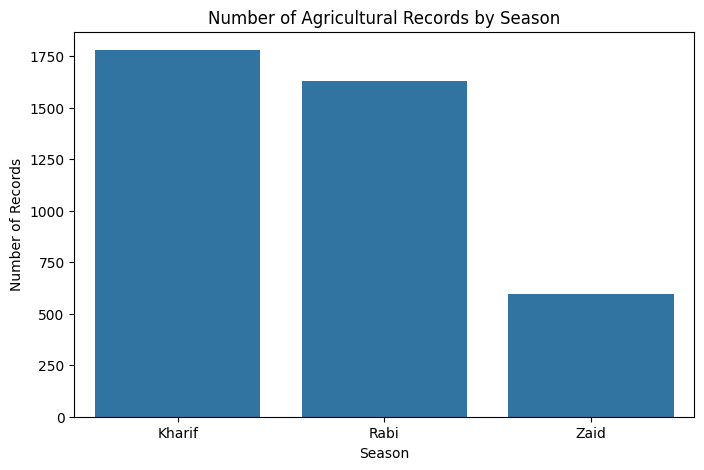

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Season")

plt.title("Number of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.show()

### Observation

The distribution of agricultural records varies across the seasons.
The graph shows the number of observations available for each season.
This distribution should be considered when comparing seasonal
agricultural performance.

In [34]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean()

print(season_yield)

Season
Kharif    5.629438
Rabi      5.038451
Zaid      4.638872
Name: Yield_Tonnes_Ha, dtype: float64


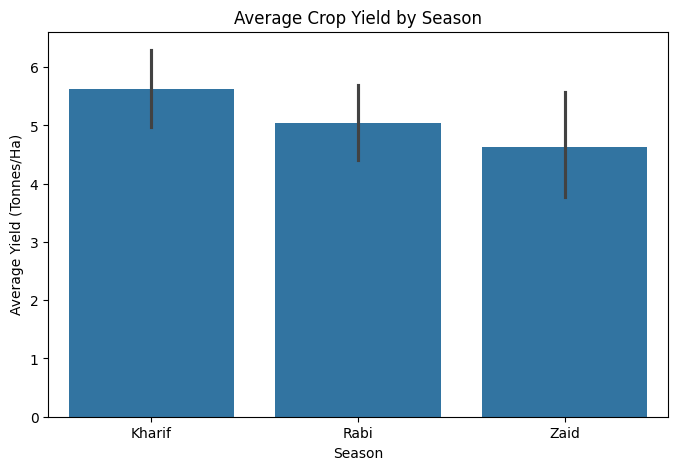

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.show()

In [36]:
season_profit = df.groupby("Season")["Profit_INR"].mean()

print(season_profit)

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


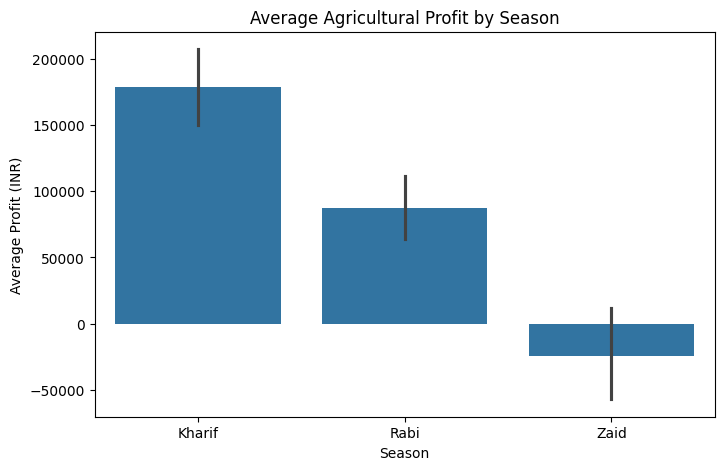

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR"
)

plt.title("Average Agricultural Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.show()

In [38]:
economic_analysis = df.groupby("Season").agg({
    "Revenue_INR": "mean",
    "Total_Cost_INR": "mean",
    "Profit_INR": "mean"
})

economic_analysis

,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,
Kharif,710719.055649,531804.408094,178914.647555
Rabi,601526.048556,513836.578365,87689.470191
Zaid,519171.904040,543976.728956,-24804.824916


In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/kjoshna7/Seasonal-Agriculture-Performance-Analysis/refs/heads/main/seasonal_agriculture_performance_dataset%20(1).csv"

df = pd.read_csv(url)

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
rainfall_season = df.groupby("Season")["Rainfall_mm"].agg(
    ["mean", "min", "max"]
)

rainfall_season

,mean,min,max
Season,,,
Kharif,852.084205,160.5,1395.2
Rabi,436.000124,80.0,1146.5
Zaid,299.421784,80.0,708.3


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/kjoshna7/Seasonal-Agriculture-Performance-Analysis/refs/heads/main/seasonal_agriculture_performance_dataset%20(1).csv"

df = pd.read_csv(url)

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [44]:
df.shape


(4000, 28)

In [45]:
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].median())

df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(
    df["Soil_Moisture_pct"].median()
)

df["Yield_Tonnes_Ha"] = df.groupby("Season")["Yield_Tonnes_Ha"].transform(
    lambda x: x.fillna(x.median())
)

In [46]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [47]:
rainfall_season = df.groupby("Season")["Rainfall_mm"].agg(
    ["mean", "min", "max"]
)

rainfall_season

,mean,min,max
Season,,,
Kharif,849.199663,160.5,1395.2
Rabi,437.615366,80.0,1146.5
Zaid,304.654714,80.0,708.3


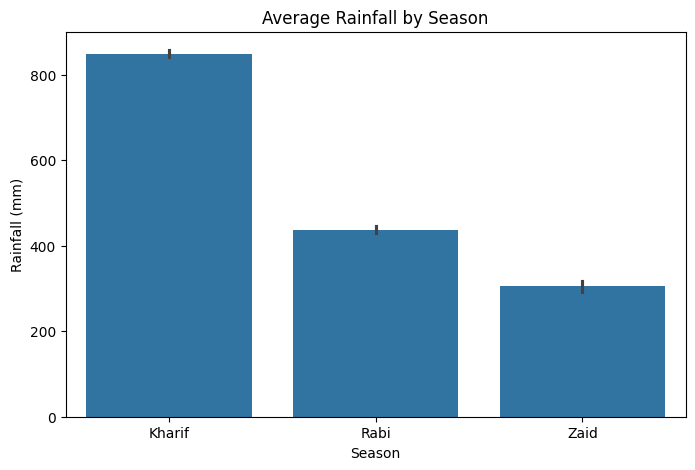

In [48]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x="Season", y="Rainfall_mm")

plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")

plt.show()

In [49]:
temperature_season = df.groupby("Season")["Avg_Temperature_C"].agg(
    ["mean", "min", "max"]
)

temperature_season

,mean,min,max
Season,,,
Kharif,28.454019,19.4,36.8
Rabi,23.489183,16.2,31.1
Zaid,31.042088,24.5,39.7


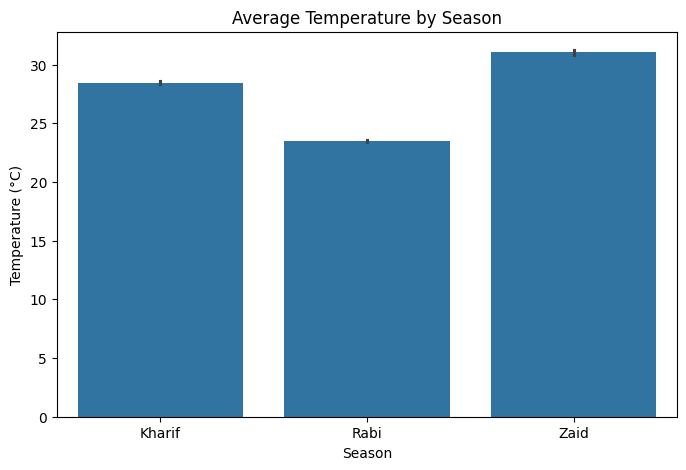

In [50]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x="Season", y="Avg_Temperature_C")

plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")

plt.show()

In [51]:
soil_moisture = df.groupby("Season")["Soil_Moisture_pct"].mean()

soil_moisture

,Soil_Moisture_pct
Season,
Kharif,31.149859
Rabi,24.069392
Zaid,19.279630


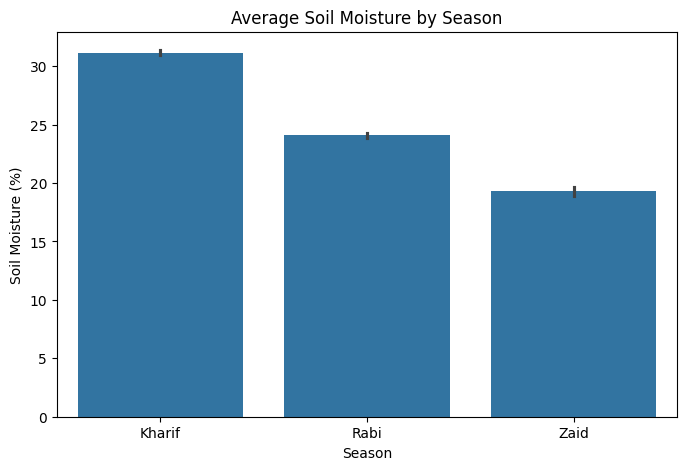

In [52]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x="Season", y="Soil_Moisture_pct")

plt.title("Average Soil Moisture by Season")
plt.xlabel("Season")
plt.ylabel("Soil Moisture (%)")

plt.show()

In [53]:
water_season = df.groupby("Season")["Water_Used_m3"].mean()

water_season

,Water_Used_m3
Season,
Kharif,6102.201237
Rabi,5846.987093
Zaid,6419.893939


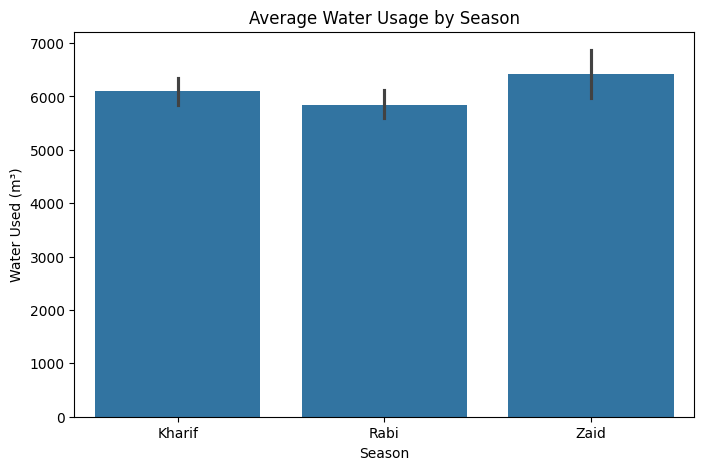

In [54]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x="Season", y="Water_Used_m3")

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")

plt.show()

In [55]:
water_efficiency = df.groupby("Season")["Water_Efficiency_t_per_1000m3"].mean()

water_efficiency

,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.891834
Rabi,5.186122
Zaid,4.413239


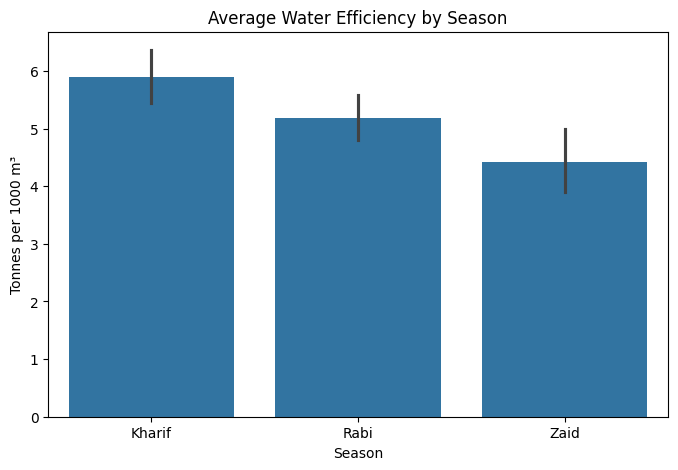

In [56]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Water_Efficiency_t_per_1000m3"
)

plt.title("Average Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1000 m³")

plt.show()

In [57]:
crop_season = df.groupby(
    ["Season", "Crop"]
)["Yield_Tonnes_Ha"].mean().reset_index()

crop_season

,Season,Crop,Yield_Tonnes_Ha
0,Kharif,Chilli,1.732595
1,Kharif,Cotton,1.375488
2,Kharif,Groundnut,1.486062
3,Kharif,Maize,2.966410
4,Kharif,Pulses,1.036063
5,Kharif,Rice,2.700382
6,Kharif,Sugarcane,53.459120
7,Kharif,Wheat,2.254384
8,Rabi,Chilli,1.464049
9,Rabi,Cotton,1.197562


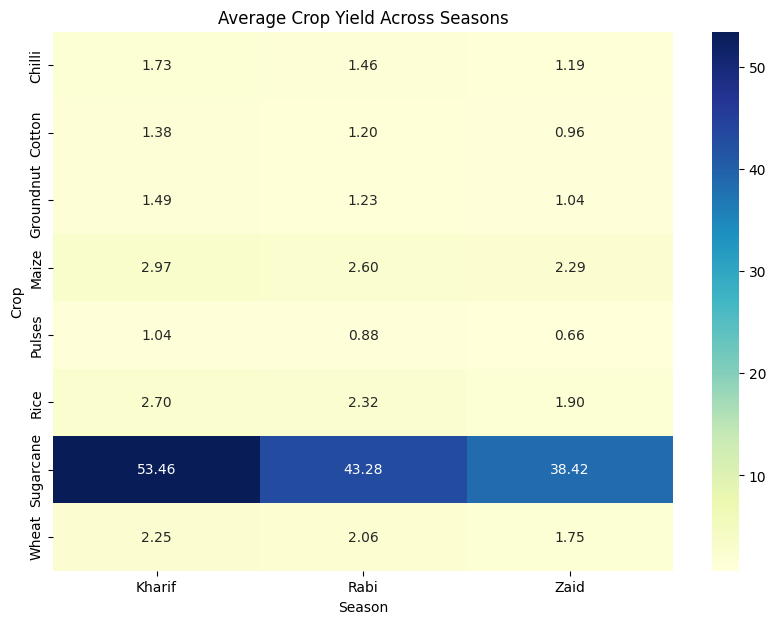

In [58]:
pivot = crop_season.pivot(
    index="Crop",
    columns="Season",
    values="Yield_Tonnes_Ha"
)

plt.figure(figsize=(10,7))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.show()

In [59]:
top_crop_per_season = (
    df.groupby(["Season", "Crop"])["Yield_Tonnes_Ha"]
    .mean()
    .reset_index()
    .sort_values(
        ["Season", "Yield_Tonnes_Ha"],
        ascending=[True, False]
    )
    .groupby("Season")
    .head(1)
)

top_crop_per_season

,Season,Crop,Yield_Tonnes_Ha
6,Kharif,Sugarcane,53.459120
14,Rabi,Sugarcane,43.284884
22,Zaid,Sugarcane,38.423922


In [60]:
irrigation_analysis = df.groupby("Irrigation_Method").agg({
    "Yield_Tonnes_Ha": "mean",
    "Water_Used_m3": "mean",
    "Profit_INR": "mean"
}).sort_values("Yield_Tonnes_Ha", ascending=False)

irrigation_analysis

,Yield_Tonnes_Ha,Water_Used_m3,Profit_INR
Irrigation_Method,,,
Drip,6.577290,5918.747541,219625.997814
Sprinkler,5.160082,6208.258856,91121.079019
Flood,4.863366,8026.472519,73354.022901
Rainfed,4.602392,3549.554275,79050.365034


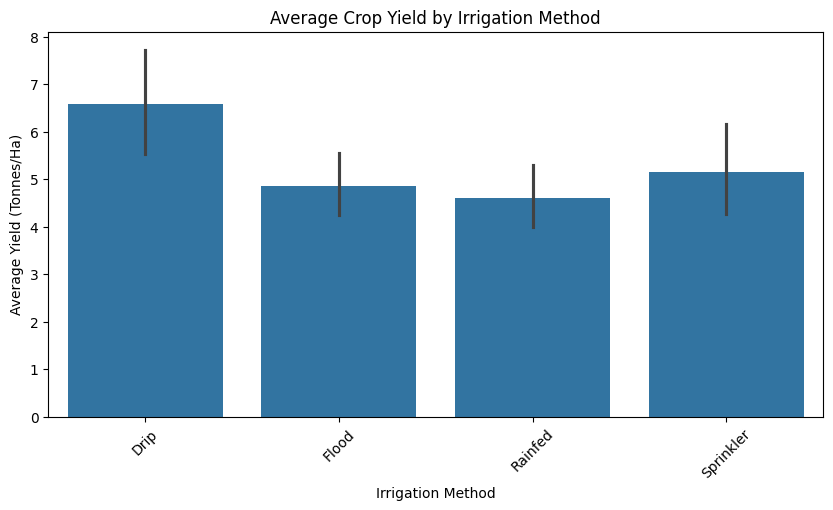

In [61]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha"
)

plt.title("Average Crop Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.show()

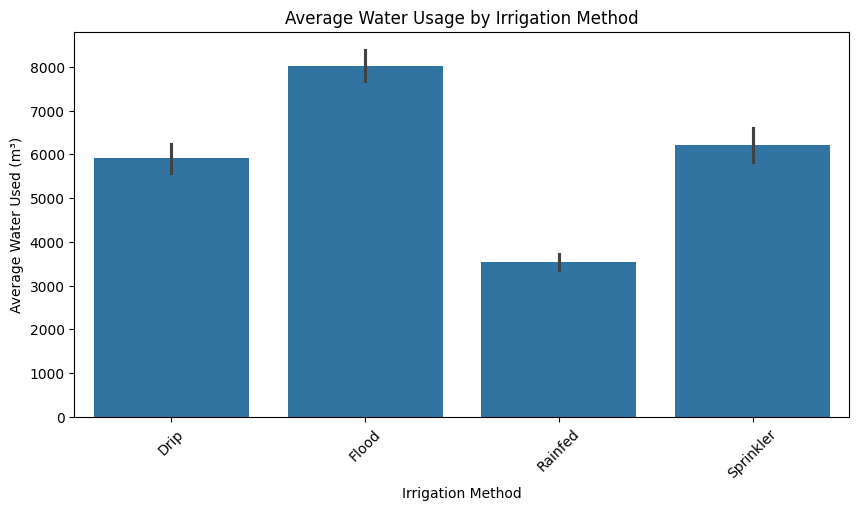

In [62]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Irrigation_Method",
    y="Water_Used_m3"
)

plt.title("Average Water Usage by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Water Used (m³)")
plt.xticks(rotation=45)

plt.show()

In [63]:
fertilizer_season = df.groupby("Season")["Fertilizer_kg_ha"].agg(
    ["mean", "min", "max"]
)

fertilizer_season

,mean,min,max
Season,,,
Kharif,187.077965,40.0,381.3
Rabi,185.407068,40.0,400.0
Zaid,184.638047,40.0,400.0


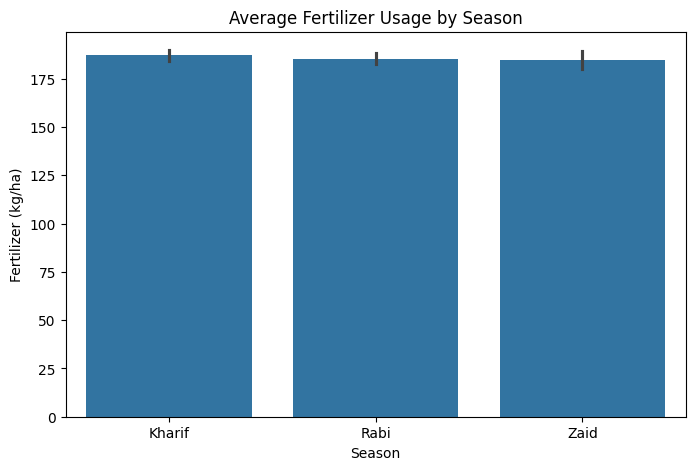

In [64]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Fertilizer_kg_ha"
)

plt.title("Average Fertilizer Usage by Season")
plt.xlabel("Season")
plt.ylabel("Fertilizer (kg/ha)")

plt.show()

In [65]:
pesticide_season = df.groupby("Season")["Pesticide_Litre_ha"].agg(
    ["mean", "min", "max"]
)

pesticide_season

,mean,min,max
Season,,,
Kharif,5.079747,0.5,11.80
Rabi,5.024690,0.5,12.08
Zaid,5.171212,0.5,11.78


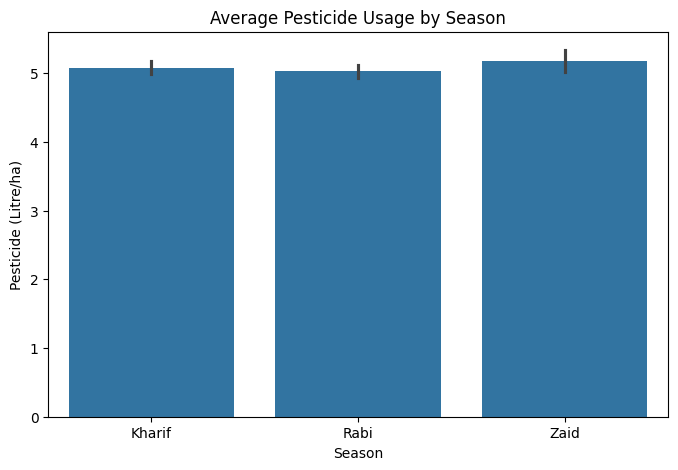

In [66]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Pesticide_Litre_ha"
)

plt.title("Average Pesticide Usage by Season")
plt.xlabel("Season")
plt.ylabel("Pesticide (Litre/ha)")

plt.show()

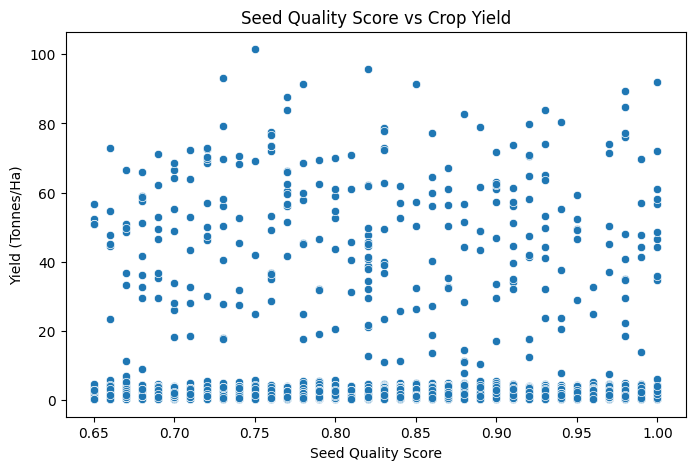

In [67]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Seed_Quality_Score",
    y="Yield_Tonnes_Ha"
)

plt.title("Seed Quality Score vs Crop Yield")
plt.xlabel("Seed Quality Score")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [68]:
seed_yield_corr = df["Seed_Quality_Score"].corr(
    df["Yield_Tonnes_Ha"]
)

print("Correlation between Seed Quality and Yield:", seed_yield_corr)

Correlation between Seed Quality and Yield: -0.007230577257397996


In [69]:
correlation = df[
    [
        "Rainfall_mm",
        "Avg_Temperature_C",
        "Humidity_pct",
        "Soil_Moisture_pct",
        "Nitrogen_kg_ha",
        "Phosphorus_kg_ha",
        "Potassium_kg_ha",
        "Fertilizer_kg_ha",
        "Pesticide_Litre_ha",
        "Seed_Quality_Score",
        "Water_Used_m3",
        "Yield_Tonnes_Ha"
    ]
].corr()

correlation["Yield_Tonnes_Ha"].sort_values(ascending=False)

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Used_m3,0.386298
Nitrogen_kg_ha,0.053167
Phosphorus_kg_ha,0.047974
Rainfall_mm,0.031030
Humidity_pct,0.012337
Soil_Moisture_pct,0.011063
Avg_Temperature_C,0.010026
Potassium_kg_ha,0.003363
Fertilizer_kg_ha,-0.000003


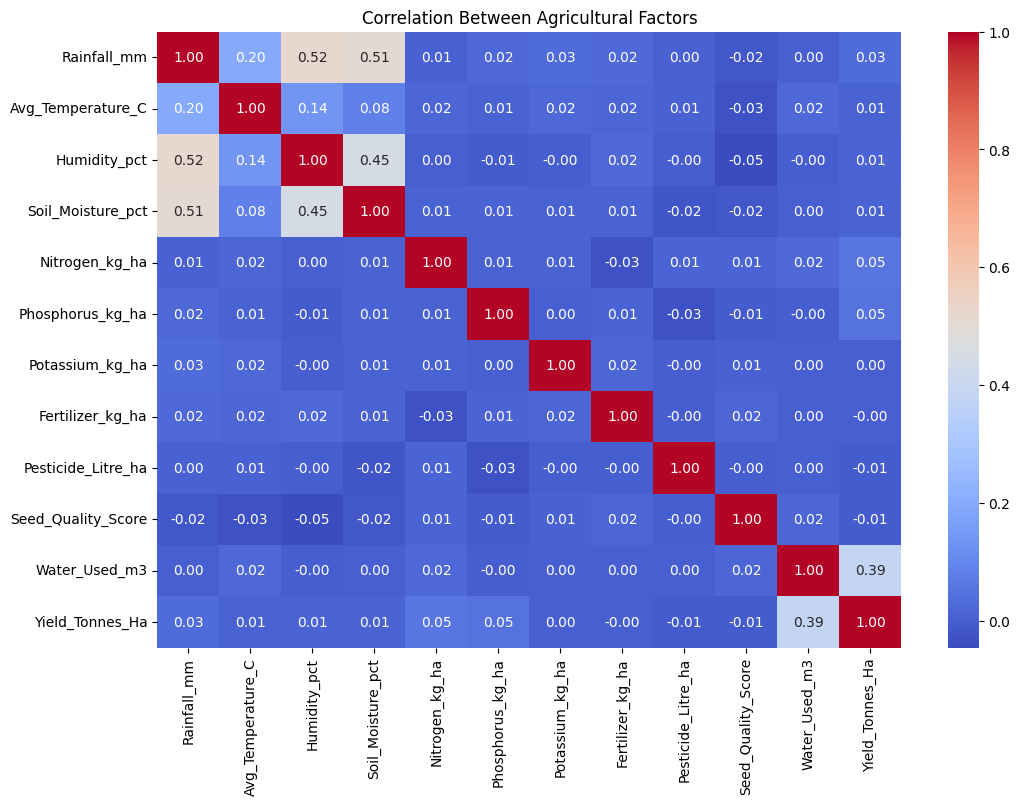

In [70]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Agricultural Factors")
plt.show()

In [71]:
yield_correlation = correlation["Yield_Tonnes_Ha"].sort_values(
    ascending=False
)

yield_correlation

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Used_m3,0.386298
Nitrogen_kg_ha,0.053167
Phosphorus_kg_ha,0.047974
Rainfall_mm,0.031030
Humidity_pct,0.012337
Soil_Moisture_pct,0.011063
Avg_Temperature_C,0.010026
Potassium_kg_ha,0.003363
Fertilizer_kg_ha,-0.000003


In [72]:
print("Strongest positive relationships:")
print(yield_correlation.iloc[1:4])

print("\nStrongest negative relationships:")
print(yield_correlation.sort_values().head(3))

Strongest positive relationships:
Water_Used_m3       0.386298
Nitrogen_kg_ha      0.053167
Phosphorus_kg_ha    0.047974
Name: Yield_Tonnes_Ha, dtype: float64

Strongest negative relationships:
Pesticide_Litre_ha   -0.007789
Seed_Quality_Score   -0.007231
Fertilizer_kg_ha     -0.000003
Name: Yield_Tonnes_Ha, dtype: float64


Water usage showed the strongest positive relationship with crop yield, with a correlation of approximately 0.386. Nitrogen and phosphorus showed very weak positive relationships with yield. Pesticide usage, seed quality, and fertilizer usage showed correlations close to zero. Therefore, water usage appears to be the most strongly associated factor with yield among the variables examined. However, correlation does not imply causation.

In [73]:
from scipy.stats import f_oneway

kharif = df[df["Season"] == "Kharif"]["Yield_Tonnes_Ha"]
rabi = df[df["Season"] == "Rabi"]["Yield_Tonnes_Ha"]
zaid = df[df["Season"] == "Zaid"]["Yield_Tonnes_Ha"]

anova_result = f_oneway(kharif, rabi, zaid)

print("F-statistic:", anova_result.statistic)
print("P-value:", anova_result.pvalue)

F-statistic: 1.5538356974366145
P-value: 0.21156310504881187


ANOVA Test Result:
A one-way ANOVA test was performed to determine whether crop yield differs significantly across Kharif, Rabi, and Zaid seasons. The test produced an F-statistic of 1.5538 and a p-value of 0.2116. Since the p-value is greater than 0.05, the difference in mean crop yield across seasons is not statistically significant at the 5% significance level.

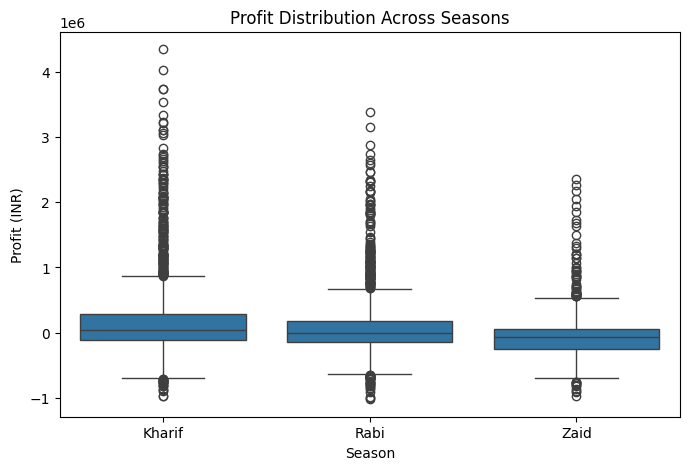

In [74]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Season",
    y="Profit_INR"
)

plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.show()

In [75]:
crop_yield = (
    df.groupby("Crop")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

crop_yield

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.641836
Maize,2.709074
Rice,2.431638
Wheat,2.108225
Chilli,1.541481
Groundnut,1.322642
Cotton,1.229311
Pulses,0.920766


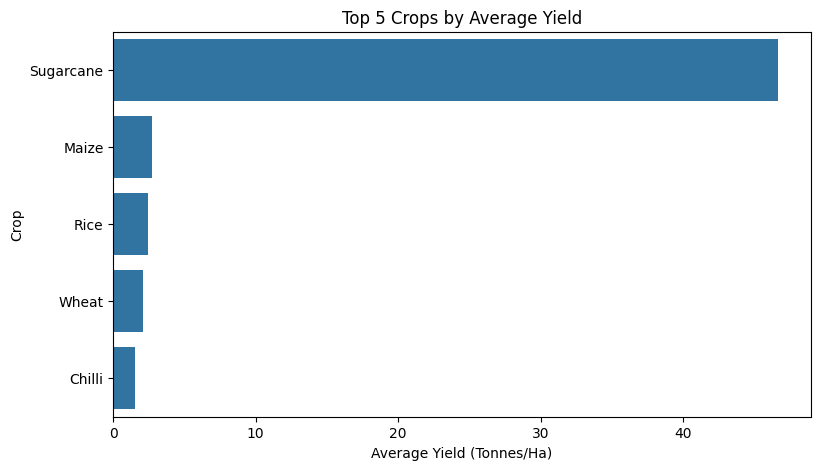

In [76]:
top_5_crops = crop_yield.head(5)

plt.figure(figsize=(9,5))

sns.barplot(
    x=top_5_crops.values,
    y=top_5_crops.index
)

plt.title("Top 5 Crops by Average Yield")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("Crop")

plt.show()

In [77]:
state_yield = (
    df.groupby("State")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

state_yield

,Yield_Tonnes_Ha
State,
Punjab,6.121116
Karnataka,5.686278
Gujarat,5.657766
Telangana,5.043857
Maharashtra,5.017324
Madhya Pradesh,4.989135
Tamil Nadu,4.874515
Andhra Pradesh,4.628318


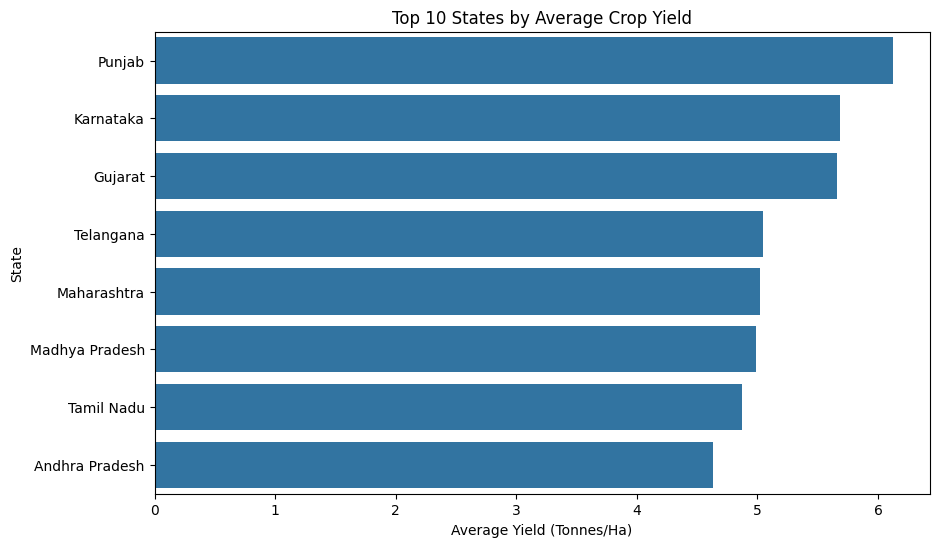

In [78]:
top_10_states = state_yield.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_10_states.values,
    y=top_10_states.index
)

plt.title("Top 10 States by Average Crop Yield")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("State")

plt.show()

In [79]:
state_profit = (
    df.groupby("State")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

state_profit.head(10)

,Profit_INR
State,
Punjab,136025.636364
Maharashtra,135428.855469
Karnataka,119422.335378
Tamil Nadu,117744.748454
Gujarat,117568.235656
Telangana,108829.616279
Madhya Pradesh,86840.756539
Andhra Pradesh,73453.527410


In [80]:
risk_season = df.groupby("Season")["Disease_Pest_Risk_pct"].agg(
    ["mean", "min", "max"]
)

risk_season

,mean,min,max
Season,,,
Kharif,54.467903,21.3,88.9
Rabi,40.482114,5.1,71.2
Zaid,38.216667,5.0,71.6


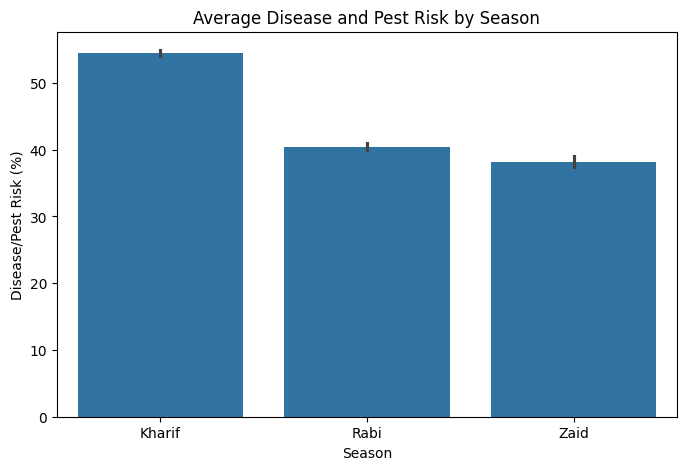

In [81]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Disease_Pest_Risk_pct"
)

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Disease/Pest Risk (%)")

plt.show()

In [82]:
crop_risk = (
    df.groupby("Crop")["Disease_Pest_Risk_pct"]
    .mean()
    .sort_values(ascending=False)
)

crop_risk.head(10)

,Disease_Pest_Risk_pct
Crop,
Wheat,47.854723
Pulses,46.570161
Rice,46.495797
Groundnut,46.289151
Chilli,46.062136
Cotton,45.974606
Maize,45.539564
Sugarcane,45.403934


In [83]:
final_summary = df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Profit_INR": "mean",
    "Rainfall_mm": "mean",
    "Avg_Temperature_C": "mean",
    "Soil_Moisture_pct": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
}).round(2)

final_summary

,Yield_Tonnes_Ha,Profit_INR,Rainfall_mm,Avg_Temperature_C,Soil_Moisture_pct,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.63,178914.65,849.20,28.45,31.15,6102.20,5.89,54.47
Rabi,5.04,87689.47,437.62,23.49,24.07,5846.99,5.19,40.48
Zaid,4.64,-24804.82,304.65,31.04,19.28,6419.89,4.41,38.22


Key Findings
Kharif season showed the highest average yield, at approximately 5.63 tonnes/ha, followed by Rabi at 5.04 tonnes/ha and Zaid at 4.64 tonnes/ha.
Kharif was the most profitable season, with an average profit of approximately ₹178,914.65 per farm.
Rabi generated an average profit of ₹87,689.47, which was substantially lower than Kharif but remained positive.
Zaid recorded a negative average profit of approximately ₹24,804.82, indicating comparatively poor economic performance in this dataset.
Rainfall varied considerably across seasons. Kharif received the highest average rainfall (849.20 mm), while Zaid received the lowest (304.65 mm).
Zaid had the highest average temperature (31.04°C), while Rabi had the lowest (23.49°C).
Kharif had the highest average soil moisture (31.15%), whereas Zaid had the lowest (19.28%).
Zaid used the highest average amount of water (6,419.89 m³), while Rabi used the lowest (5,846.99 m³).
Kharif had the highest water efficiency, producing approximately 5.89 tonnes per 1,000 m³ of water, compared with 5.19 for Rabi and 4.41 for Zaid.
Disease and pest risk was highest during Kharif (54.47%), followed by Rabi (40.48%) and Zaid (38.22%).
Water usage had the strongest positive correlation with crop yield, with a correlation coefficient of approximately 0.386. Other analyzed factors showed very weak relationships with yield.
The ANOVA test produced a p-value of 0.2116, which is greater than 0.05. Therefore, the observed differences in mean crop yield across Kharif, Rabi, and Zaid were not statistically significant at the 5% significance level.

Recommendations
Prioritize Kharif-season agricultural planning, as it showed the highest average yield, profit, and water efficiency.
Improve water management during Zaid, since Zaid had the highest average water usage but the lowest water efficiency.
Investigate the causes of low profitability in Zaid, particularly production costs, market prices, water requirements, and crop selection.
Use efficient irrigation practices to improve water productivity and reduce unnecessary water consumption.
Strengthen disease and pest management during Kharif, as it showed the highest average disease/pest risk.
Select crops according to seasonal suitability, using the Crop × Season analysis to identify crops with better yield performance in each season.
Consider regional differences when planning agricultural activities because yield and profit performance can vary between states.

# Data Cleaning and Preparation

The dataset was checked for missing values and duplicate records before
performing the analysis.

Missing values in `Rainfall_mm` and `Soil_Moisture_pct` were replaced using
median imputation. Missing values in `Yield_Tonnes_Ha` were replaced using
the median yield of the corresponding season.

Duplicate records were also checked before analysis.

In [84]:
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(
    df["Rainfall_mm"].median()
)

df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(
    df["Soil_Moisture_pct"].median()
)

df["Yield_Tonnes_Ha"] = df.groupby("Season")["Yield_Tonnes_Ha"].transform(
    lambda x: x.fillna(x.median())
)

In [85]:
print("Dataset Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Dataset Shape: (4000, 28)
Total Missing Values: 0
Duplicate Rows: 0


# Conclusion

This project analyzed agricultural performance across Kharif, Rabi, and Zaid
seasons using environmental, resource, crop, economic, regional, and risk-related
factors.

The analysis showed that Kharif had the highest average yield of 5.63 tonnes/ha,
the highest average profit of approximately ₹178,914.65, and the highest water
efficiency of 5.89 tonnes per 1,000 m³. Rabi showed moderate performance, while
Zaid recorded the lowest average yield of 4.64 tonnes/ha and a negative average
profit of approximately ₹24,804.82.

Environmental conditions also varied considerably across seasons. Kharif had
the highest average rainfall and soil moisture, while Zaid had the highest
average temperature and water usage. Kharif also showed the highest disease and
pest risk.

Correlation analysis indicated that water usage had the strongest positive
relationship with crop yield, with a correlation of approximately 0.386.
However, the one-way ANOVA test produced a p-value of 0.2116, indicating that
the differences in mean crop yield across the three seasons were not
statistically significant at the 5% significance level.

Overall, the findings highlight the importance of efficient water management,
seasonally suitable crop selection, effective disease and pest management, and
regional agricultural planning. These insights can support farmers and
agricultural planners in making more informed, data-driven decisions to improve
productivity and economic performance.